# Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import wordcloud
from wordcloud import STOPWORDS

import re
import sys

# Setup aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Paths
DATA_DIR = Path("../data/interim")

# Load Parquet files
print("Loading data...")
%time df_books = pd.read_parquet(DATA_DIR / "books.parquet")
%time df_interactions = pd.read_parquet(DATA_DIR / "interactions.parquet")

print("\n--- Data Shapes ---")
print(f"Books: {df_books.shape}")
print(f"Interactions: {df_interactions.shape}")

Loading data...
CPU times: user 466 ms, sys: 190 ms, total: 656 ms
Wall time: 3.59 s
CPU times: user 2.63 s, sys: 1.37 s, total: 4 s
Wall time: 2.58 s

--- Data Shapes ---
Books: (258585, 9)
Interactions: (55397550, 5)


## Basic EDA

In [16]:
print("1. NULL VALUES AUDIT")
print("--- Books Nulls ---")
print(df_books.isnull().sum())

print("\n--- Interactions Nulls ---")
print(df_interactions.isnull().sum())

print("2. DUPLICATE CHECK")
# Check for duplicate user-book interactions (e.g. user rated the same book twice)
dup_interactions = df_interactions.duplicated(subset=['user_id', 'book_id']).sum()
print(f"Duplicate (user_id, book_id) pairs in Interactions: {dup_interactions:,}")

# Check for duplicate book IDs in metadata
dup_books = df_books.duplicated(subset=['book_id']).sum()
print(f"Duplicate book_ids in Metadata: {dup_books:,}")

1. NULL VALUES AUDIT
--- Books Nulls ---
book_id                 0
title                   0
description             0
average_rating          0
ratings_count           0
publication_year    62511
num_pages           82241
image_url               0
author_ids              0
dtype: int64

--- Interactions Nulls ---
user_id             0
book_id             0
rating              0
is_read             0
interaction_date    0
dtype: int64
2. DUPLICATE CHECK
Duplicate (user_id, book_id) pairs in Interactions: 0
Duplicate book_ids in Metadata: 0


In [21]:
print("NUMERICAL SANITY CHECKS")
print(df_books[['average_rating', 'ratings_count', 'publication_year', 'num_pages']].describe())

# Check extreme publication years
invalid_years = df_books[(df_books['publication_year'] < 1800) | (df_books['publication_year'] > 2018)]
print(f"\nBooks with unusual publication years (<1800 or >2018): {len(invalid_years):,}")

# Check page counts
zero_pages = (df_books['num_pages'] == 0).sum() + df_books['num_pages'].isnull().sum()
print(f"Books with 0 or missing page counts: {zero_pages:,} ({zero_pages/len(df_books)*100:.2f}%)")

NUMERICAL SANITY CHECKS
       average_rating  ratings_count  publication_year      num_pages
count   258585.000000   2.585850e+05     196074.000000  176344.000000
mean         3.941336   8.404962e+02       2010.545911     308.572234
std          0.364376   1.917309e+04        226.400763     285.858104
min          0.000000   0.000000e+00          2.000000       0.000000
25%          3.730000   1.300000e+01       2009.000000     192.000000
50%          3.960000   4.200000e+01       2012.000000     300.000000
75%          4.180000   1.560000e+02       2014.000000     387.000000
max          5.000000   4.765497e+06      65535.000000   82000.000000

Books with unusual publication years (<1800 or >2017): 550
Books with 0 or missing page counts: 83,098 (32.14%)


Handle outliers later, set unusual publication years to Null. Keep Null page counts if we don't have them.

In [22]:
# Measure description word counts
df_books['desc_word_count'] = df_books['description'].fillna("").str.split().str.len()

print("BOOK DESCRIPTION QUALITY FOR VECTOR DB")
print(df_books['desc_word_count'].describe(percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9]))

# Count unusable descriptions (< 10 words)
short_desc = (df_books['desc_word_count'] < 10).sum()
print(f"\nBooks with fewer than 10 words in description: {short_desc:,} ({short_desc/len(df_books)*100:.2f}%)")

BOOK DESCRIPTION QUALITY FOR VECTOR DB
count    258585.000000
mean        133.125452
std          87.905034
min           0.000000
5%            0.000000
10%          27.000000
25%          79.000000
50%         129.000000
75%         175.000000
90%         227.000000
max        3752.000000
Name: desc_word_count, dtype: float64

Books with fewer than 10 words in description: 21,842 (8.45%)


Books with so few words will not be useful in our vector database, we should just use the title.

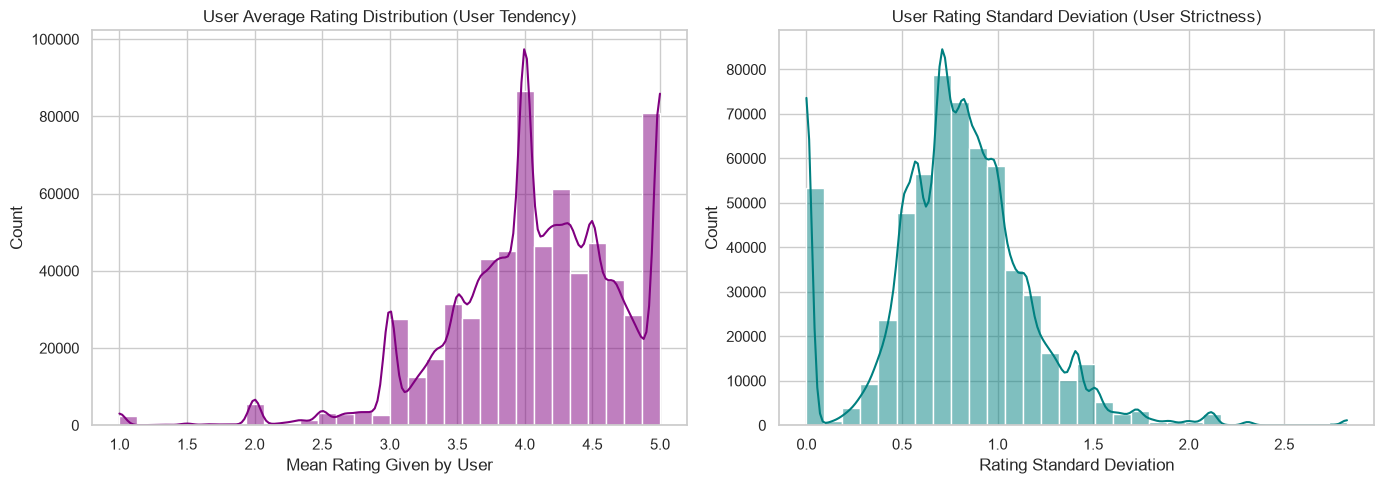

In [19]:
# Filter for explicit ratings only (1 to 5 stars)
explicit_ratings = df_interactions[df_interactions['rating'] > 0]

user_stats = explicit_ratings.groupby('user_id').agg(
    user_avg_rating=('rating', 'mean'),
    user_rating_std=('rating', 'std'),
    user_rating_count=('rating', 'count')
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot User Average Rating Distribution
sns.histplot(user_stats['user_avg_rating'], bins=30, ax=ax[0], color="purple", kde=True)
ax[0].set_title("User Average Rating Distribution (User Tendency)")
ax[0].set_xlabel("Mean Rating Given by User")

# Plot Rating Variance (Standard Deviation)
sns.histplot(user_stats['user_rating_std'].dropna(), bins=30, ax=ax[1], color="teal", kde=True)
ax[1].set_title("User Rating Standard Deviation (User Strictness)")
ax[1].set_xlabel("Rating Standard Deviation")

plt.tight_layout()
plt.show()

These graphs are what we expect, five star ratings systems like these are heavily skewed to the left. Additionally, the spike at 0 in the rating standard deviation contains no useable signal if there are more than one ratings given for a user (every rating given is the same).

## Orphan Check

In [23]:
interaction_books = set(df_interactions['book_id'])
metadata_books = set(df_books['book_id'])

missing_in_metadata = interaction_books - metadata_books
missing_in_interactions = metadata_books - interaction_books

print(f"Total Unique Interacted Books: {len(interaction_books):,}")
print(f"Total Unique Metadata Books: {len(metadata_books):,}")
print(f"Interacted books MISSING from Metadata: {len(missing_in_metadata):,}")
print(f"Metadata books with ZERO Interactions (Cold-Start Items): {len(missing_in_interactions):,}")

Total Unique Interacted Books: 258,585
Total Unique Metadata Books: 258,585
Interacted books MISSING from Metadata: 0
Metadata books with ZERO Interactions (Cold-Start Items): 0


## Temporal Distribution & Train/Test Split Boundary

--- Interaction Date Range ---
Earliest Interaction: 2006-08-29 03:00:42
Latest Interaction:   2017-11-05 06:33:00


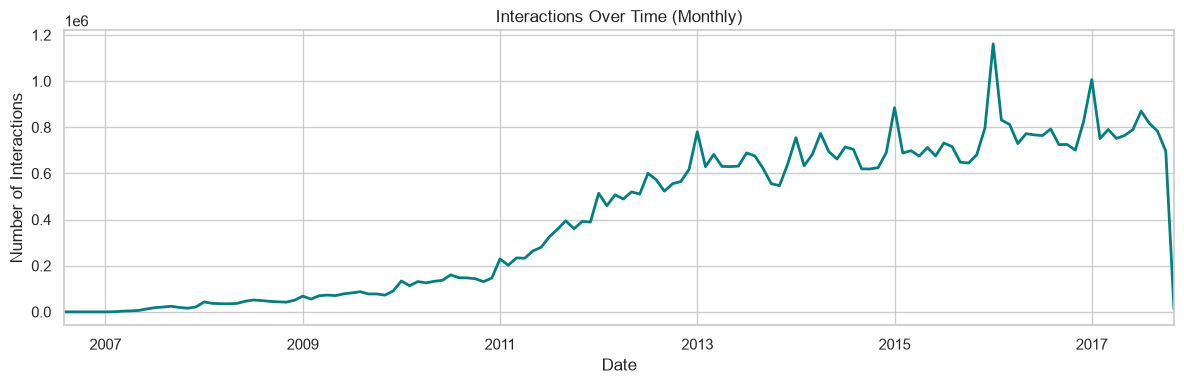

In [25]:
df_interactions['interaction_date'] = pd.to_datetime(df_interactions['interaction_date'])

print("--- Interaction Date Range ---")
print(f"Earliest Interaction: {df_interactions['interaction_date'].min()}")
print(f"Latest Interaction:   {df_interactions['interaction_date'].max()}")

# Plot interactions over time
df_interactions['year_month'] = df_interactions['interaction_date'].dt.to_period('M')
monthly_counts = df_interactions.groupby('year_month').size()

plt.figure(figsize=(12, 4))
monthly_counts.plot(kind='line', color='teal', linewidth=2)
plt.title("Interactions Over Time (Monthly)")
plt.xlabel("Date")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

### Split the data into before June 2017 as Training and After as Validation/Testing

## Author Coverage & Entity Disambiguation

In [26]:
# Explode the list of author_ids
df_authors = df_books.explode('author_ids')

total_authors = df_authors['author_ids'].nunique()
books_without_author = df_books['author_ids'].apply(lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0).eq(0).sum()

print(f"Total Unique Authors: {total_authors:,}")
print(f"Books without any author listed: {books_without_author:,}")

# Top authors by book count
top_authors = df_authors['author_ids'].value_counts().head(10)
print("\nTop 10 Most Prolific Author IDs:\n", top_authors)

Total Unique Authors: 69,008
Books without any author listed: 2

Top 10 Most Prolific Author IDs:
 author_ids
1654       1679
656983     1424
346732     1360
1221698    1351
1077326    1309
150038     1054
3389       1006
15872       882
9494        818
1069006     778
Name: count, dtype: int64


## Check Data for Useability in Graph

In [4]:
# Calculate unique nodes
unique_users = df_interactions["user_id"].nunique()
unique_books = df_interactions["book_id"].nunique()

total_possible_edges = unique_users * unique_books
actual_edges = len(df_interactions)

sparsity = (1 - (actual_edges / total_possible_edges)) * 100

print(f"Unique Users (U): {unique_users:,}")
print(f"Unique Books (I): {unique_books:,}")
print(f"Total Interactions (Edges): {actual_edges:,}")
print(f"Matrix Sparsity: {sparsity:.4f}%")

Unique Users (U): 726,932
Unique Books (I): 258,585
Total Interactions (Edges): 55,397,550
Matrix Sparsity: 99.9705%


Matrix sparsity is comparable to other production grade datasets like Amazon, Netflix. Around 76 interactions per user and 214 interactions per book, but most likely this is heavily concentrated on the extreme tail.

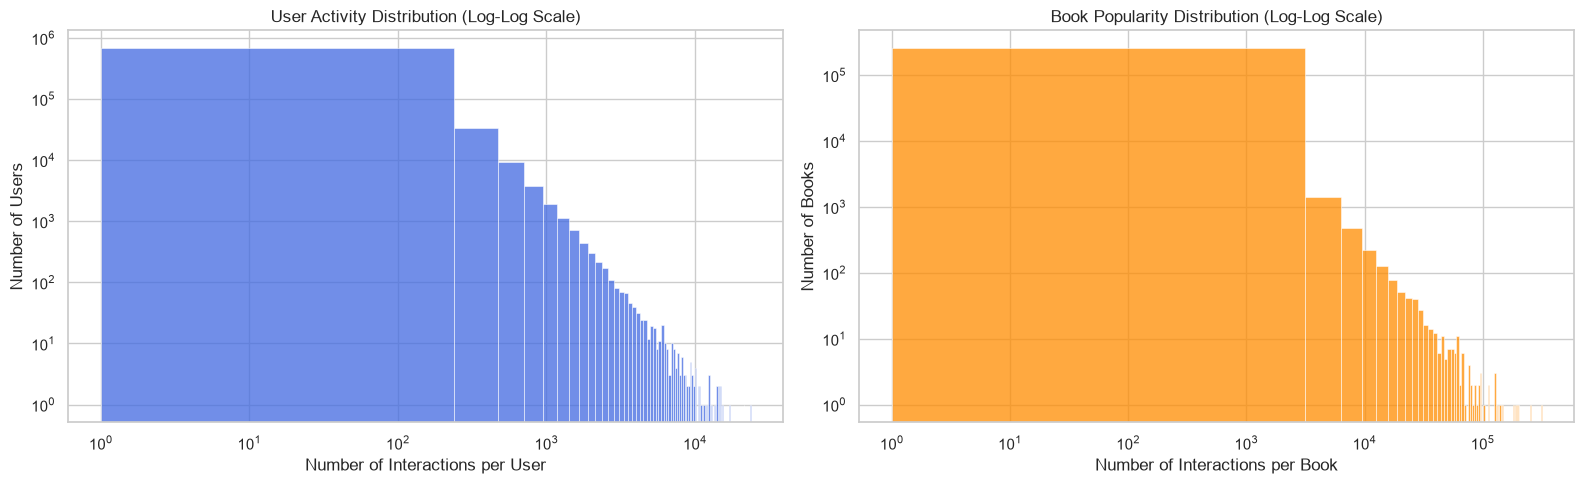

--- User Activity Quantiles ---
count    726932.000000
mean         76.207334
std         226.666847
min           1.000000
25%           6.000000
50%          20.000000
75%          68.000000
90%         180.000000
95%         308.000000
max       23636.000000
dtype: float64


In [7]:
# Group interactions
user_activity = df_interactions.groupby('user_id').size()
book_popularity = df_interactions.groupby('book_id').size()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Plot User Activity
# Note: we removed log_scale=True and use standard bins, then scale the axis
sns.histplot(user_activity, bins=100, ax=ax[0], color="royalblue")
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_title("User Activity Distribution (Log-Log Scale)")
ax[0].set_xlabel("Number of Interactions per User")
ax[0].set_ylabel("Number of Users")

# Plot Book Popularity
sns.histplot(book_popularity, bins=100, ax=ax[1], color="darkorange")
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_title("Book Popularity Distribution (Log-Log Scale)")
ax[1].set_xlabel("Number of Interactions per Book")
ax[1].set_ylabel("Number of Books")

plt.tight_layout()
plt.show()

print("--- User Activity Quantiles ---")
print(user_activity.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]))

/var/folders/l1/86nzlvlj3313vn4h__34jl100000gn/T/ipykernel_5569/2061242642.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_interactions, x="rating", palette="viridis", ax=ax[0])
/var/folders/l1/86nzlvlj3313vn4h__34jl100000gn/T/ipykernel_5569/2061242642.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_interactions, x="is_read", palette="Set2", ax=ax[1])


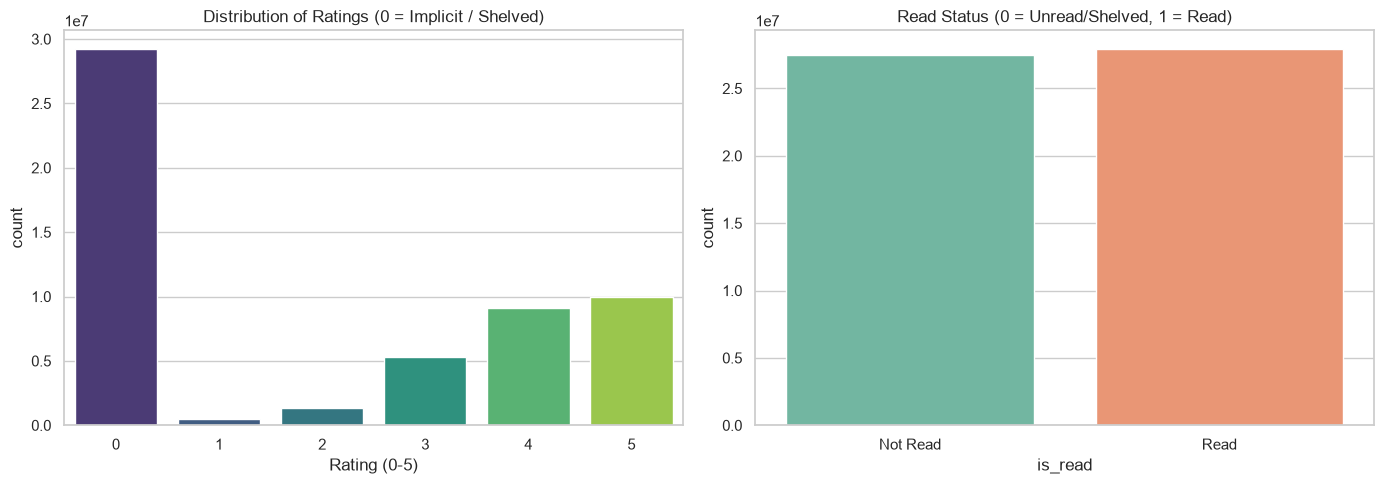

Books marked as 'Read' but given a 0 rating: 1,710,270


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Explicit Ratings
sns.countplot(data=df_interactions, x="rating", palette="viridis", ax=ax[0])
ax[0].set_title("Distribution of Ratings (0 = Implicit / Shelved)")
ax[0].set_xlabel("Rating (0-5)")

# Plot Read Status
sns.countplot(data=df_interactions, x="is_read", palette="Set2", ax=ax[1])
ax[1].set_title("Read Status (0 = Unread/Shelved, 1 = Read)")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["Not Read", "Read"])

plt.tight_layout()
plt.show()

# Quick check on how many 0-ratings are actually marked as read
read_but_zero = len(df_interactions[(df_interactions['rating'] == 0) & (df_interactions['is_read'] == 1)])
print(f"Books marked as 'Read' but given a 0 rating: {read_but_zero:,}")

## Fun Word Cloud

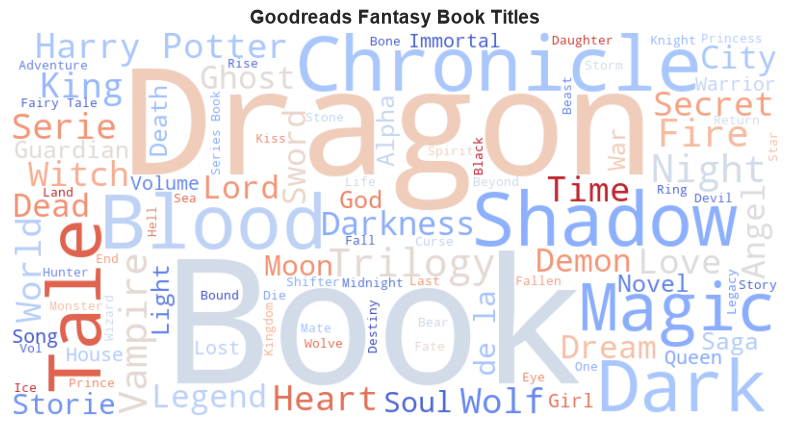

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all book titles into a single long string
text = " ".join(df_books['title'].dropna())

# Generate the word cloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    max_words=100, 
    colormap='coolwarm'
).generate(text)

# Render the plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Goodreads Fantasy Book Titles", fontsize=14, fontweight='bold')
plt.show()